# Import Libraries

In [ ]:
%matplotlib inline
import imageio
import scipy.io
import scipy.misc
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt

from scipy import linalg
from random import sample
from kneed import KneeLocator
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

---
# Load Data

In [3]:
dataset = pd.read_csv('tsne_scores.csv')
dataset.shape

(4406, 2)

In [4]:
dataset.head()

,t-SNE-1,t-SNE-2
0,10.846841,-16.712580
1,24.794334,-16.775398
2,2.953309,13.379048
3,27.262146,-31.886690
4,-23.015728,64.468376


In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4406 entries, 0 to 4405
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   t-SNE-1  4406 non-null   float64
 1   t-SNE-2  4406 non-null   float64
 2   cluster  4406 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 103.4 KB


In [13]:
dataset.isnull().sum()

t-SNE-1    0
t-SNE-2    0
cluster    0
dtype: int64

---
# DBSCAN Parameter Selection
In this section, the minimum number of points (`minPts`) is set to twice the number of data dimensions. The epsilon (`eps`) value is determined using the kNN method and the knee point identified by `KneeLocator`.

In [ ]:
# Determine minPts and eps for DBSCAN
# Use only feature columns, excluding an existing cluster column if present
features = dataset.drop(columns=['cluster'], errors='ignore')
n_features = features.shape[1]
minPts = 2 * n_features

# Compute k-nearest-neighbor distances (k = minPts)
neigh = NearestNeighbors(n_neighbors=minPts)
nbrs = neigh.fit(features)
distances, indices = nbrs.kneighbors(features)
distances = np.sort(distances[:, -1])  # Distance to the minPts-th nearest neighbor for each point

# Find the elbow point to determine eps
kneedle = KneeLocator(range(len(distances)), distances, S=1.0, curve='convex', direction='increasing')
eps = distances[kneedle.knee] if kneedle.knee is not None else np.percentile(distances, 90)  # If no elbow is found, use the 90th percentile
print(f"minPts: {minPts}, eps: {eps}")

minPts: 4, eps: 2.512446571811066


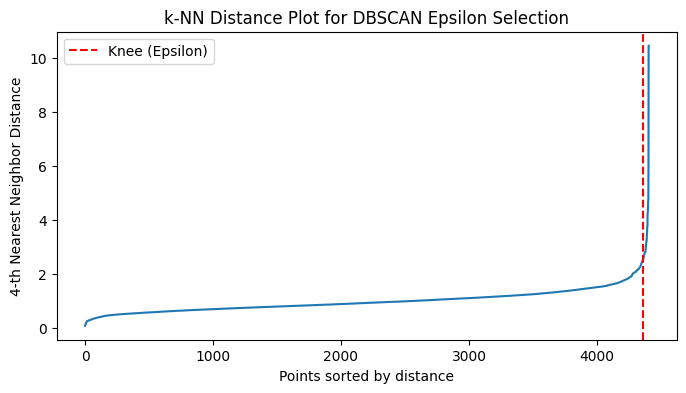

In [ ]:
# Plot the k-nearest neighbor distance graph to inspect the knee point
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{minPts}-th Nearest Neighbor Distance')
plt.title('k-NN Distance Plot for DBSCAN Epsilon Selection')
if kneedle.knee is not None:
    plt.axvline(kneedle.knee, color='r', linestyle='--', label='Knee (Epsilon)')
    plt.legend()
plt.show()

---
# Running DBSCAN and Displaying the Results
In this section, the clustering is performed using the obtained parameters, and the results are visualized in the feature space.

cluster
 1     1501
 0      834
 2      703
 3      285
 7      283
 5      245
 6      232
 4      145
 12      46
-1       34
 11      13
 9       11
 8       11
 15      10
 16       8
 18       8
 14       6
 10       5
 19       5
 20       5
 13       4
 17       4
 21       4
 22       4
Name: count, dtype: int64


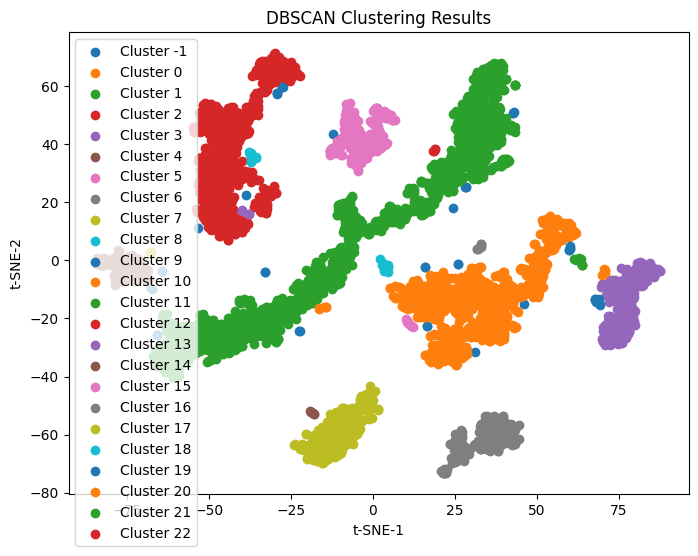

In [ ]:
# Run DBSCAN with the selected parameters
dbscan = DBSCAN(eps=eps, min_samples=minPts)
labels = dbscan.fit_predict(dataset)

# Add cluster labels to the dataset
dataset['cluster'] = labels

# Show the number of points in each cluster
print(dataset['cluster'].value_counts())

# Plot clustering results in 2D (if the data has two feature dimensions)
if dataset.shape[1] - 1 == 2:
    plt.figure(figsize=(8, 6))
    for cluster in np.unique(labels):
        mask = dataset['cluster'] == cluster
        plt.scatter(
            dataset.loc[mask, dataset.columns[0]],
            dataset.loc[mask, dataset.columns[1]],
            label=f'Cluster {cluster}'
        )
    plt.xlabel(dataset.columns[0])
    plt.ylabel(dataset.columns[1])
    plt.title('DBSCAN Clustering Results')
    plt.legend()
    plt.show()
else:
    print('The data has more than two dimensions. Dimensionality reduction is required for visualization.')